In [3]:
!pip install a2pm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 967.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 30.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, bu

In [4]:
!pip show a2pm

Name: a2pm
Version: 1.2.0
Summary: Adaptative Perturbation Pattern Method
Home-page: https://github.com/vitorinojoao/a2pm
Author: João Vitorino
Author-email: jpmvo@outlook.com
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, scikit-learn
Required-by: 


In [6]:
!pip install -q "numpy>=1.17.5,<2.0" --upgrade

In [12]:
import numpy as np
import pandas as pd
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

from a2pm import A2PMethod
from a2pm.patterns import IntervalPattern

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("All imports successful.")

All imports successful.


In [13]:
DATA_PATH = (
    "/content/drive/MyDrive/final_dataset/"
    "iot_cleaned_sampled_smotenc(hybrid70-30)/"
    "preprocessed_dataset_with_shadow.csv"
)
SAVE_DIR = (
    "/content/drive/MyDrive/final_dataset/"
    "iot_cleaned_sampled_smotenc(hybrid70-30)/models/adversarial/"
)
os.makedirs(SAVE_DIR, exist_ok=True)

processed_df = pd.read_csv(DATA_PATH)
print(f"Dataset shape : {processed_df.shape}")

label_cols   = ['Binary_Label', 'Superclass', 'Fine_Label']
feature_cols = [c for c in processed_df.columns if c not in label_cols]
print(f"Features ({len(feature_cols)}): {feature_cols}")

X         = processed_df[feature_cols]           # DataFrame
y_binary  = processed_df['Binary_Label'].values  # numpy
s         = processed_df['Superclass']           # Series — may contain NaN
fine_label = processed_df['Fine_Label']

nan_count = s.isna().sum()
print(f"\nClass distribution — Benign: {(y_binary==0).sum():,}  Attack: {(y_binary==1).sum():,}")
print(f"NaN in Superclass (SMOTE artifacts): {nan_count:,}")

# Exact split — must match all other experiments
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y_binary, s,
    test_size=0.2,
    stratify=fine_label,
    random_state=42
)

print(f"\nTrain : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Test  — Attack: {(y_test==1).sum():,}  Benign: {(y_test==0).sum():,}")

Dataset shape : (2782400, 18)
Features (15): ['https', 'ack_flag_number', 'time_to_live', 'psh_flag_number', 'ack_count', 'tcp', 'header_length', 'rate', 'tot sum', 'iat', 'avg', 'std', 'min', 'udp', 'syn_flag_number']

Class distribution — Benign: 987,598  Attack: 1,794,802
NaN in Superclass (SMOTE artifacts): 28,870

Train : 2,225,920  |  Test : 556,480
Test  — Attack: 358,960  Benign: 197,520


In [14]:
MODEL_PATH = (
    "/content/drive/MyDrive/final_dataset/"
    "iot_cleaned_sampled_smotenc(hybrid70-30)/models/xgboost_model.pkl"
)

with open(MODEL_PATH, 'rb') as f:
    xgb_model = pickle.load(f)
print(f"Model loaded: {type(xgb_model).__name__}")

y_pred_clean = xgb_model.predict(X_test).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_clean, labels=[0, 1]).ravel()
baseline_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_clean),
    'F1'       : f1_score(y_test, y_pred_clean, zero_division=0),
    'FNR'      : fn / (fn + tp),
    'FPR'      : fp / (fp + tn),
    'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
}

print(f"\n{'='*45}")
print("  Baseline XGBoost — Clean Test Data")
print(f"{'='*45}")
print(f"  Accuracy : {baseline_metrics['Accuracy']*100:.2f}%")
print(f"  F1       : {baseline_metrics['F1']:.4f}")
print(f"  FNR      : {baseline_metrics['FNR']*100:.2f}%")
print(f"  FPR      : {baseline_metrics['FPR']*100:.4f}%")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")


Model loaded: XGBClassifier

  Baseline XGBoost — Clean Test Data
  Accuracy : 92.80%
  F1       : 0.9425
  FNR      : 8.54%
  FPR      : 4.7545%
  TP=328306  TN=188129  FP=9391  FN=30654


In [15]:
def evaluate(y_true, y_pred, label=""):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics = dict(
        Label=label, Accuracy=acc, F1=f1, FNR=fnr, FPR=fpr,
        TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn)
    )
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc*100:.2f}%   F1 : {f1:.4f}")
    print(f"  FNR      : {fnr*100:.2f}%   FPR: {fpr*100:.4f}%")
    print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    return metrics


def superclass_breakdown(y_pred, s_labels, y_true, title=""):
    """
    Per-superclass detection rate table.
    NaN superclass rows (SMOTE artifacts) are excluded from the table
    but are included in all aggregate metrics — they are noted in output.
    """
    y_true  = np.asarray(y_true)
    y_pred  = np.asarray(y_pred)
    s_str   = pd.Series(np.asarray(s_labels, dtype=object)).astype(str).reset_index(drop=True)

    nan_attack_count = ((s_str == 'nan') & (y_true == 1)).sum()
    if nan_attack_count > 0:
        print(f"\n  [{title}] Note: {nan_attack_count} attack samples have NaN Superclass "
              f"(SMOTE artifacts) — excluded from table below, included in all metrics.")

    valid   = (~(s_str == 'nan')) & (y_true == 1)
    classes = sorted(s_str[valid].unique())

    rows = []
    for cls in classes:
        m         = (s_str == cls) & (y_true == 1)
        total     = int(m.sum())
        detected  = int((y_pred[m] == 1).sum())
        evaded    = total - detected
        dr        = detected / total if total > 0 else 0.0
        rows.append({
            'Superclass'     : cls,
            'Total'          : total,
            'Detected'       : detected,
            'Evaded'         : evaded,
            'Detection Rate' : f"{dr:.1%}",
        })

    df = pd.DataFrame(rows)
    print(f"\n{title}")
    print(df.to_string(index=False))
    return df


def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Benign', 'Attack'],
        yticklabels=['Benign', 'Attack'],
        cbar=False
    )
    ax.set_title(f"{title}\nFNR={fnr:.2%}  FPR={fpr:.4%}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

print("Helpers defined.")


Helpers defined.


In [16]:
attack_mask    = (y_test == 1)          # numpy boolean array
benign_mask    = (y_test == 0)

X_test_attack  = X_test[attack_mask]   # DataFrame — attack rows of test set
X_train_attack = X_train[y_train == 1] # DataFrame — attack rows of train set

print(f"Test attack samples  : {len(X_test_attack):,}")
print(f"Train attack samples : {len(X_train_attack):,}")

# Bounds computed from training attack samples only (not the full training set)
feat_min = X_train_attack.min()
feat_max = X_train_attack.max()

bounds_df = pd.DataFrame({
    'Feature'         : feature_cols,
    'Train_Attack_Min': feat_min.values,
    'Train_Attack_Max': feat_max.values,
    'Range'           : (feat_max - feat_min).values,
})
print("\nFeature bounds (from training attack samples):")
print(bounds_df.to_string(index=False))


Test attack samples  : 358,960
Train attack samples : 1,435,842

Feature bounds (from training attack samples):
        Feature  Train_Attack_Min  Train_Attack_Max        Range
          https          0.000000             1.000 1.000000e+00
ack_flag_number          0.000000             1.000 1.000000e+00
   time_to_live          0.000000           255.000 2.550000e+02
psh_flag_number          0.000000             1.000 1.000000e+00
      ack_count          0.000000           100.000 1.000000e+02
            tcp          0.000000             1.000 1.000000e+00
  header_length          0.000000            60.000 6.000000e+01
           rate          0.001208       7340032.000 7.340032e+06
        tot sum         60.000000        316492.000 3.164320e+05
            iat          0.000000         45978.470 4.597847e+04
            avg         46.000000          5022.000 4.976000e+03
            std          0.000000         10625.816 1.062582e+04
            min         42.000000          

In [17]:
class XGBWrapper:
    """Wraps XGBoost so A2PM can call .predict() and receive integer labels."""
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        return self.model.predict(X).astype(int)


xgb_wrapper = XGBWrapper(xgb_model)

# Single IntervalPattern covering all 15 features
pattern = IntervalPattern(
    ratio       = 0.1,   # perturbation step as fraction of each feature's interval
    probability = 0.7,   # per-feature perturbation probability per iteration
    momentum    = 0.99,
    seed        = 42,
)

a2pm_model = A2PMethod(pattern=pattern, seed=42)

# Fit on training attack samples — learns valid interval per feature
print("Fitting A2PM on training attack samples...")
a2pm_model.fit(
    X_train_attack.values,
    y=np.ones(len(X_train_attack), dtype=int),
)
print("Fit complete.\n")

# Generate: y_target=0 means perturb until classifier predicts Benign (evasion)
print(f"Generating adversarial samples for {len(X_test_attack):,} attack samples ...")
print("(iterations=10, patience=2 — may take several minutes)\n")

X_adv = a2pm_model.generate(
    classifier = xgb_wrapper,
    X          = X_test_attack.values,
    y          = np.ones(len(X_test_attack), dtype=int),
    y_target   = np.zeros(len(X_test_attack), dtype=int),
    iterations = 30,
    patience   = 5,
)

print(f"Generation complete.  Shape: {X_adv.shape}")

# Per-sample perturbation delta — used in Cells 7, 8, 11
delta = X_adv - X_test_attack.values   # (n_attack, n_features)

# Reconstruct full test set: benign rows unchanged, attack rows replaced
X_full_adv_values            = X_test.values.copy()
X_full_adv_values[attack_mask] = X_adv
X_full_adv = pd.DataFrame(X_full_adv_values, columns=feature_cols, index=X_test.index)

# Evaluate
y_pred_a2pm = xgb_model.predict(X_full_adv).astype(int)
a2pm_metrics = evaluate(y_test, y_pred_a2pm, "A2PM Adversarial Attack (full test set)")

# Evasion rate on attack subset only
evasion_rate = (y_pred_a2pm[attack_mask] == 0).mean()
print(f"\n  Attack-subset evasion rate : {evasion_rate:.2%}  "
      f"({int(evasion_rate * attack_mask.sum())} / {attack_mask.sum()} attacks evade detection)")

# Robustness gap vs clean baseline
rob_gap_acc = baseline_metrics['Accuracy'] - a2pm_metrics['Accuracy']
rob_gap_fnr = a2pm_metrics['FNR']          - baseline_metrics['FNR']

print(f"\n{'─'*45}")
print("  Robustness Gap  (A2PM vs Clean)")
print(f"{'─'*45}")
print(f"  Accuracy drop   : {rob_gap_acc*100:.2f} pp")
print(f"  FNR increase    : {rob_gap_fnr*100:.2f} pp")
print(f"\n  FGSM/BIM ref    : ~0.00 pp  (gradient collapse, 99.8% zero grads)")
print(f"  A2PM gap        : {rob_gap_acc*100:.2f} pp  ← genuine robustness deficit")


Fitting A2PM on training attack samples...
Fit complete.

Generating adversarial samples for 358,960 attack samples ...
(iterations=10, patience=2 — may take several minutes)

Generation complete.  Shape: (358960, 15)

  A2PM Adversarial Attack (full test set)
  Accuracy : 75.14%   F1 : 0.7688
  FNR      : 35.92%   FPR: 4.7545%
  TP=230033  TN=188129  FP=9391  FN=128927

  Attack-subset evasion rate : 35.92%  (128926 / 358960 attacks evade detection)

─────────────────────────────────────────────
  Robustness Gap  (A2PM vs Clean)
─────────────────────────────────────────────
  Accuracy drop   : 17.66 pp
  FNR increase    : 27.38 pp

  FGSM/BIM ref    : ~0.00 pp  (gradient collapse, 99.8% zero grads)
  A2PM gap        : 17.66 pp  ← genuine robustness deficit


In [18]:
# delta is available from Cell 6: X_adv - X_test_attack.values

violations_per_feature = {}
for i, feat in enumerate(feature_cols):
    below = int((X_adv[:, i] < feat_min[feat]).sum())
    above = int((X_adv[:, i] > feat_max[feat]).sum())
    violations_per_feature[feat] = {
        'Below Min'        : below,
        'Above Max'        : above,
        'Total Violations' : below + above,
        'Mean |Δ|'         : np.abs(delta[:, i]).mean(),
    }

total_cells = X_adv.shape[0] * X_adv.shape[1]
total_viols = sum(v['Total Violations'] for v in violations_per_feature.values())
viol_rate   = total_viols / total_cells

print(f"\n{'='*55}")
print("  Realism Check — A2PM Adversarial Samples")
print(f"{'='*55}")
print(f"  Adversarial samples  : {X_adv.shape[0]:,}")
print(f"  Total feature cells  : {total_cells:,}")
print(f"  Constraint violations: {total_viols}  ({viol_rate:.2%})")
print(f"\n  FGSM/BIM reference   : 62.3%  (floating-point artifacts, mean|Δ|≈0)")
print(f"  A2PM violation rate  : {viol_rate:.2%}  ← near 0% (genuinely constrained)")

viol_df = pd.DataFrame([
    {
        'Feature'          : feat,
        'Below Min'        : v['Below Min'],
        'Above Max'        : v['Above Max'],
        'Total Violations' : v['Total Violations'],
        'Mean |Δ|'         : f"{v['Mean |Δ|']:.6f}",
    }
    for feat, v in violations_per_feature.items()
])
print("\nPer-feature violation breakdown:")
print(viol_df.to_string(index=False))

# Sample-level: how many adversarial samples are fully in-bounds?
sample_viols = np.array([
    sum(
        1 for i, feat in enumerate(feature_cols)
        if X_adv[j, i] < feat_min[feat] or X_adv[j, i] > feat_max[feat]
    )
    for j in range(X_adv.shape[0])
])
in_bounds = (sample_viols == 0).sum()
print(f"\n  Samples fully in-bounds : {in_bounds:,} / {len(sample_viols):,}  "
      f"({in_bounds/len(sample_viols):.1%})")
print(f"  Max violations per sample : {sample_viols.max()}")



  Realism Check — A2PM Adversarial Samples
  Adversarial samples  : 358,960
  Total feature cells  : 5,384,400
  Constraint violations: 0  (0.00%)

  FGSM/BIM reference   : 62.3%  (floating-point artifacts, mean|Δ|≈0)
  A2PM violation rate  : 0.00%  ← near 0% (genuinely constrained)

Per-feature violation breakdown:
        Feature  Below Min  Above Max  Total Violations       Mean |Δ|
          https          0          0                 0       0.277925
ack_flag_number          0          0                 0       0.265756
   time_to_live          0          0                 0      50.105552
psh_flag_number          0          0                 0       0.272465
      ack_count          0          0                 0      24.402221
            tcp          0          0                 0       0.269591
  header_length          0          0                 0      13.097263
           rate          0          0                 0 1865425.957393
        tot sum          0          0     

In [19]:
# delta from Cell 6
abs_delta = np.abs(delta)
changed   = abs_delta > 0   # boolean mask

print(f"\n{'='*55}")
print("  Perturbation Analysis — A2PM")
print(f"{'='*55}")

feat_rows = [
    {
        'Feature'            : feat,
        'Mean |Δ|'           : f"{abs_delta[:, i].mean():.6f}",
        '% Samples Changed'  : f"{changed[:, i].mean()*100:.1f}%",
    }
    for i, feat in enumerate(feature_cols)
]
print("\nPer-feature statistics:")
print(pd.DataFrame(feat_rows).to_string(index=False))

n_changed = changed.sum(axis=1)   # features changed per sample
print(f"\nFeatures perturbed per adversarial sample:")
print(f"  Mean   : {n_changed.mean():.2f} / {len(feature_cols)}")
print(f"  Median : {np.median(n_changed):.1f}")
print(f"  Range  : {n_changed.min()} – {n_changed.max()}")
print(f"  Samples with 0 features changed : {(n_changed==0).sum():,}  "
      f"({(n_changed==0).mean():.1%})  ← already evading before perturbation")

print("\nDistribution (features changed per sample):")
for k in range(len(feature_cols) + 1):
    cnt = int((n_changed == k).sum())
    if cnt == 0:
        continue
    bar = '█' * max(1, int(cnt / len(n_changed) * 40))
    print(f"  {k:2d} features : {cnt:5,}  {bar}")

global_mean = abs_delta.mean()
print(f"\nGlobal mean |Δ|  : {global_mean:.6f}")
print(f"FGSM reference   : ≈0.000000  (zero gradients → no real perturbation)")
print(f"A2PM             : {global_mean:.6f}  ← genuine, measurable perturbations")



  Perturbation Analysis — A2PM

Per-feature statistics:
        Feature       Mean |Δ| % Samples Changed
          https       0.277925             83.9%
ack_flag_number       0.265756             83.6%
   time_to_live      50.105552             83.3%
psh_flag_number       0.272465             83.7%
      ack_count      24.402221             79.6%
            tcp       0.269591             83.3%
  header_length      13.097263             85.0%
           rate 1865425.957393             90.5%
        tot sum   76488.300256             89.3%
            iat   12509.735180             90.3%
            avg    1283.759502             89.9%
            std    2928.342443             88.8%
            min     887.831012             88.5%
            udp       0.271896             84.2%
syn_flag_number       0.264333             80.7%

Features perturbed per adversarial sample:
  Mean   : 12.85 / 15
  Median : 14.0
  Range  : 0 – 15
  Samples with 0 features changed : 30,654  (8.5%)  ← alrea

In [20]:
# Align indices for superclass_breakdown
s_test_arr = np.asarray(s_test)
y_test_arr = y_test   # already numpy

print("\n" + "="*60)
print("  SUPERCLASS DETECTION BREAKDOWN")
print("="*60)

df_clean_sc = superclass_breakdown(
    y_pred    = y_pred_clean,
    s_labels  = s_test_arr,
    y_true    = y_test_arr,
    title     = "CLEAN BASELINE — per-superclass detection rate",
)

df_a2pm_sc = superclass_breakdown(
    y_pred    = y_pred_a2pm,
    s_labels  = s_test_arr,
    y_true    = y_test_arr,
    title     = "A2PM ATTACK — per-superclass detection rate",
)

# Per-superclass evasion rate (which attack families evade most)
print("\nPer-superclass evasion rate after A2PM:")
evasion_rows = []
for _, row_c in df_clean_sc.iterrows():
    cls   = row_c['Superclass']
    total = row_c['Total']
    det_c = row_c['Detected']
    match = df_a2pm_sc[df_a2pm_sc['Superclass'] == cls]
    det_a = match.iloc[0]['Detected'] if len(match) > 0 else det_c
    evasion = (total - det_a) / total if total > 0 else 0.0
    evasion_rows.append({
        'Superclass'      : cls,
        'Total'           : total,
        'Detected (Clean)': det_c,
        'Detected (A2PM)' : det_a,
        'Evaded (A2PM)'   : total - det_a,
        'Evasion Rate'    : f"{evasion:.1%}",
    })

evasion_df = pd.DataFrame(evasion_rows).sort_values('Evasion Rate', ascending=False)
print(evasion_df.to_string(index=False))



  SUPERCLASS DETECTION BREAKDOWN

  [CLEAN BASELINE — per-superclass detection rate] Note: 5774 attack samples have NaN Superclass (SMOTE artifacts) — excluded from table below, included in all metrics.

CLEAN BASELINE — per-superclass detection rate
 Superclass  Total  Detected  Evaded Detection Rate
Brute Force   5766      5650     116          98.0%
       DDoS 139841    139835       6         100.0%
        DoS  46014     46014       0         100.0%
      Mirai  40406     40405       1         100.0%
      Recon  59609     35170   24439          59.0%
   Spoofing  26920     21270    5650          79.0%
  Web-based  34630     34188     442          98.7%

  [A2PM ATTACK — per-superclass detection rate] Note: 5774 attack samples have NaN Superclass (SMOTE artifacts) — excluded from table below, included in all metrics.

A2PM ATTACK — per-superclass detection rate
 Superclass  Total  Detected  Evaded Detection Rate
Brute Force   5766      3299    2467          57.2%
       DDoS 1398

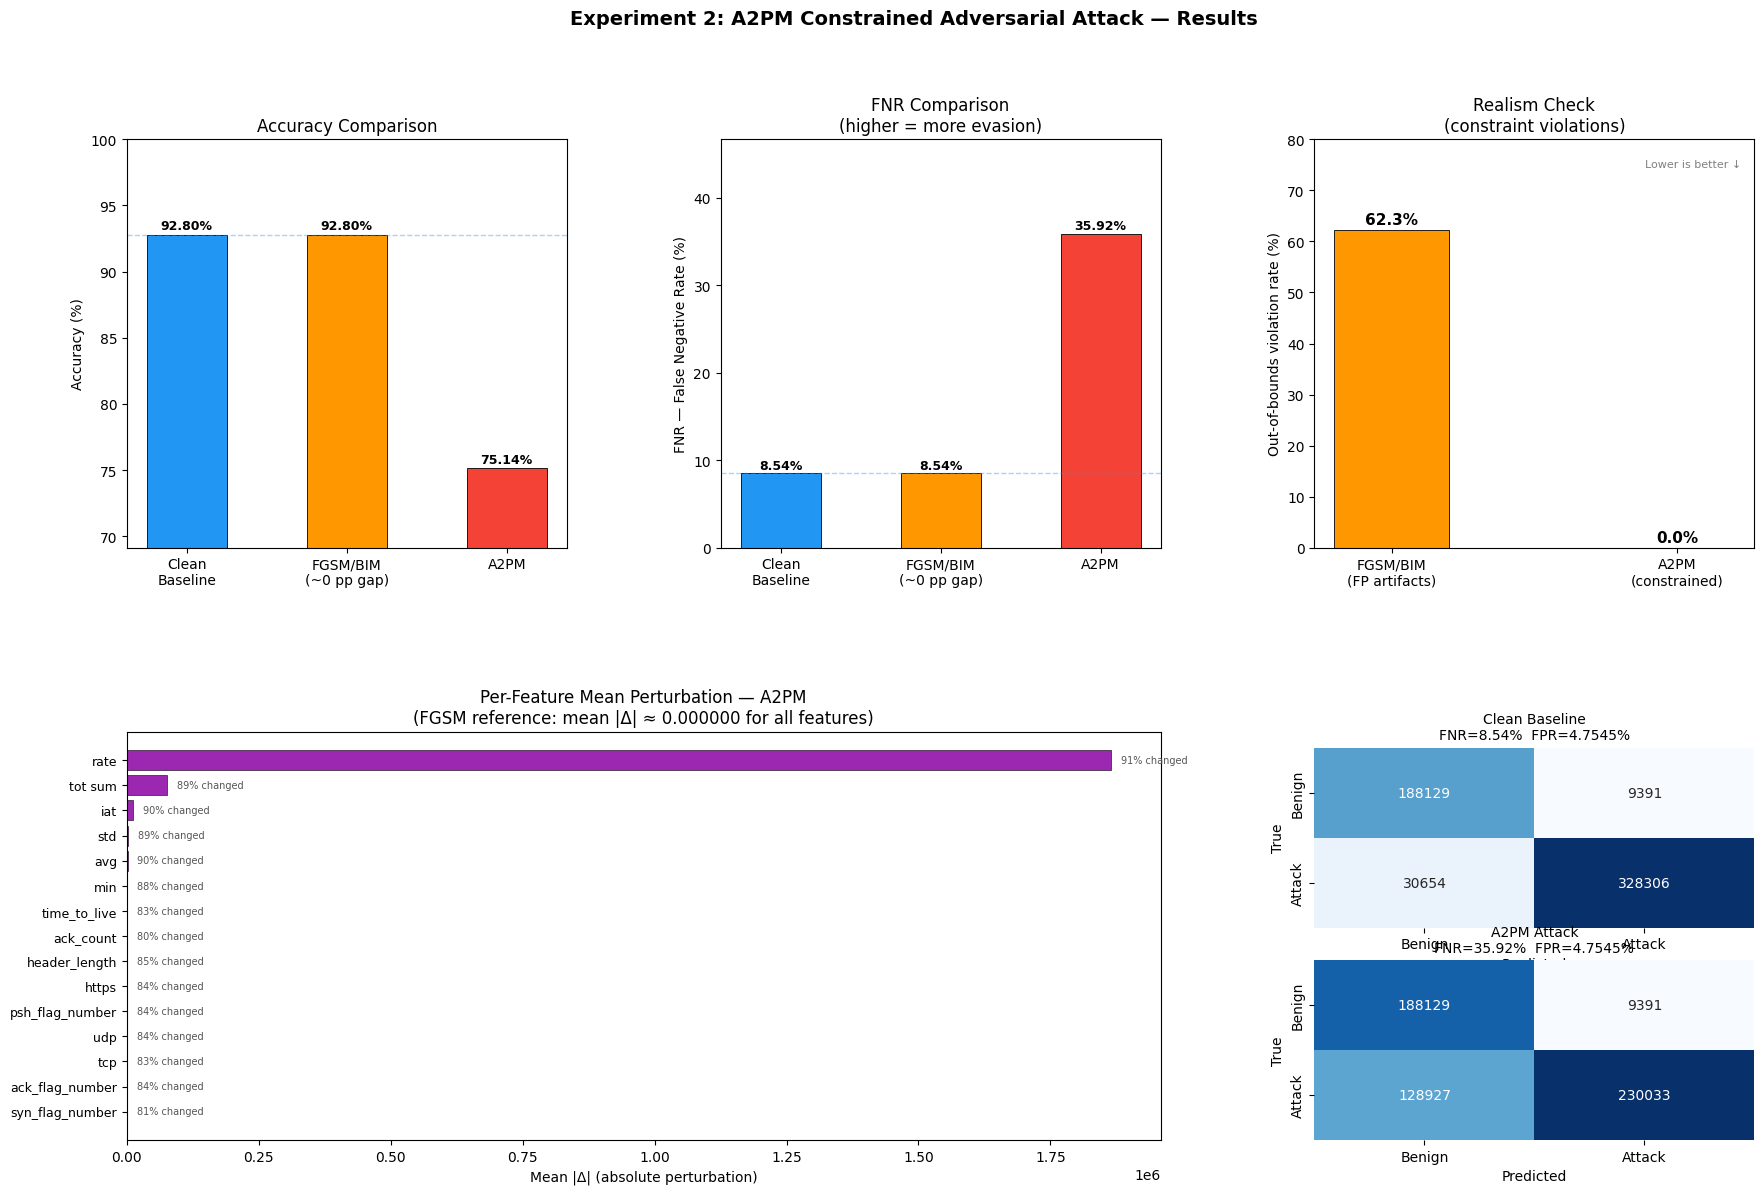

Figure saved.


In [21]:
FGSM_ACC      = baseline_metrics['Accuracy']   # ~0 pp gap
FGSM_FNR      = baseline_metrics['FNR']        # ~0 pp gap
FGSM_VIOL_PCT = 62.3                           # % from Experiment 1

fig = plt.figure(figsize=(21, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    "Experiment 2: A2PM Constrained Adversarial Attack — Results",
    fontsize=14, fontweight='bold',
)

COLORS = {'clean': '#2196F3', 'fgsm': '#FF9800', 'a2pm': '#F44336'}

# ── Row 0, Col 0 — Accuracy comparison ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
labs   = ['Clean\nBaseline', 'FGSM/BIM\n(~0 pp gap)', 'A2PM']
acc_v  = [
    baseline_metrics['Accuracy'] * 100,
    FGSM_ACC * 100,
    a2pm_metrics['Accuracy'] * 100,
]
bars = ax.bar(labs, acc_v,
              color=[COLORS['clean'], COLORS['fgsm'], COLORS['a2pm']],
              edgecolor='black', linewidth=0.6, width=0.5)
for bar, val in zip(bars, acc_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(max(0, min(acc_v) - 6), 100)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Comparison")
ax.axhline(baseline_metrics['Accuracy'] * 100, color=COLORS['clean'],
           linestyle='--', alpha=0.4, linewidth=1)

# ── Row 0, Col 1 — FNR comparison ──────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
fnr_v = [
    baseline_metrics['FNR'] * 100,
    FGSM_FNR * 100,
    a2pm_metrics['FNR'] * 100,
]
bars = ax.bar(labs, fnr_v,
              color=[COLORS['clean'], COLORS['fgsm'], COLORS['a2pm']],
              edgecolor='black', linewidth=0.6, width=0.5)
for bar, val in zip(bars, fnr_v):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(fnr_v) * 1.3)
ax.set_ylabel("FNR — False Negative Rate (%)")
ax.set_title("FNR Comparison\n(higher = more evasion)")
ax.axhline(baseline_metrics['FNR'] * 100, color=COLORS['clean'],
           linestyle='--', alpha=0.4, linewidth=1)

# ── Row 0, Col 2 — Realism violations ──────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
viol_labels = ['FGSM/BIM\n(FP artifacts)', 'A2PM\n(constrained)']
viol_vals   = [FGSM_VIOL_PCT, viol_rate * 100]
bars = ax.bar(viol_labels, viol_vals,
              color=['#FF9800', '#4CAF50'],
              edgecolor='black', linewidth=0.6, width=0.4)
for bar, val in zip(bars, viol_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 80)
ax.set_ylabel("Out-of-bounds violation rate (%)")
ax.set_title("Realism Check\n(constraint violations)")
ax.text(0.97, 0.95, "Lower is better ↓", transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='gray')

# ── Row 1, Col 0–1 — Per-feature mean perturbation ─────────────────────────
ax = fig.add_subplot(gs[1, 0:2])
mean_perturb  = abs_delta.mean(axis=0)
sort_idx      = np.argsort(mean_perturb)[::-1]
feat_sorted   = [feature_cols[i] for i in sort_idx]
perturb_sorted = mean_perturb[sort_idx]
pct_changed   = changed.mean(axis=0)[sort_idx] * 100

bars = ax.barh(range(len(feature_cols)), perturb_sorted,
               color='#9C27B0', edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feat_sorted, fontsize=9)
ax.set_xlabel("Mean |Δ| (absolute perturbation)")
ax.set_title("Per-Feature Mean Perturbation — A2PM\n"
             "(FGSM reference: mean |Δ| ≈ 0.000000 for all features)")
ax.invert_yaxis()
# Annotate % samples changed
for i, (val, pct) in enumerate(zip(perturb_sorted, pct_changed)):
    ax.text(val + max(perturb_sorted) * 0.01, i,
            f'{pct:.0f}% changed', va='center', fontsize=7, color='#555')

# ── Row 1, Col 2 — Confusion matrices (Clean & A2PM stacked) ───────────────
# Use inset axes to fit both CMs in one subplot cell
ax_parent = fig.add_subplot(gs[1, 2])
ax_parent.axis('off')

# We add two real axes manually positioned inside this subplot's bounding box
pos   = ax_parent.get_position()
left, bottom, w, h = pos.x0, pos.y0, pos.width, pos.height

ax_cm0 = fig.add_axes([left,          bottom + h*0.52, w, h*0.44])
ax_cm1 = fig.add_axes([left,          bottom,           w, h*0.44])

plot_cm(y_test, y_pred_clean, "Clean Baseline", ax_cm0)
plot_cm(y_test, y_pred_a2pm,  "A2PM Attack",    ax_cm1)

plt.savefig(
    os.path.join(SAVE_DIR, "experiment2_a2pm_results.png"),
    dpi=150, bbox_inches='tight',
)
plt.show()
print("Figure saved.")


In [22]:
summary_df = pd.DataFrame([
    {
        'Experiment'             : 'Clean Baseline',
        'Method'                 : 'XGBoost (no attack)',
        'Accuracy'               : f"{baseline_metrics['Accuracy']*100:.2f}%",
        'F1'                     : f"{baseline_metrics['F1']:.4f}",
        'FNR'                    : f"{baseline_metrics['FNR']*100:.2f}%",
        'FPR'                    : f"{baseline_metrics['FPR']*100:.4f}%",
        'Robustness Gap (Acc)'   : '—',
        'Robustness Gap (FNR)'   : '—',
        'Realism Violations'     : '—',
        'Global Mean |Δ|'        : '—',
    },
    {
        'Experiment'             : 'A2PM Adversarial Attack',
        'Method'                 : 'Interval pattern (gradient-free)',
        'Accuracy'               : f"{a2pm_metrics['Accuracy']*100:.2f}%",
        'F1'                     : f"{a2pm_metrics['F1']:.4f}",
        'FNR'                    : f"{a2pm_metrics['FNR']*100:.2f}%",
        'FPR'                    : f"{a2pm_metrics['FPR']*100:.4f}%",
        'Robustness Gap (Acc)'   : f"{rob_gap_acc*100:.2f} pp",
        'Robustness Gap (FNR)'   : f"{rob_gap_fnr*100:.2f} pp",
        'Realism Violations'     : f"{viol_rate:.2%}",
        'Global Mean |Δ|'        : f"{abs_delta.mean():.6f}",
    },
])

print("\nEXPERIMENT SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

# ── Save outputs ──────────────────────────────────────────────────────────────
summary_df.to_csv(os.path.join(SAVE_DIR, "experiment_summary.csv"), index=False)
print(f"\nSummary      → {SAVE_DIR}experiment_summary.csv")

adv_out                 = X_full_adv.copy()
adv_out['y_true']       = y_test
adv_out['y_pred_clean'] = y_pred_clean
adv_out['y_pred_a2pm']  = y_pred_a2pm
adv_out['Superclass']   = np.asarray(s_test)
adv_out.to_csv(os.path.join(SAVE_DIR, "a2pm_adversarial_test_set.csv"), index=False)
print(f"Adv test set → {SAVE_DIR}a2pm_adversarial_test_set.csv")

delta_df = pd.DataFrame(delta, columns=feature_cols)
delta_df.to_csv(os.path.join(SAVE_DIR, "a2pm_perturbations_delta.csv"), index=False)
print(f"Deltas       → {SAVE_DIR}a2pm_perturbations_delta.csv")

evasion_df.to_csv(os.path.join(SAVE_DIR, "a2pm_superclass_evasion.csv"), index=False)
print(f"Superclass   → {SAVE_DIR}a2pm_superclass_evasion.csv")

print(f"\nAll outputs saved to: {SAVE_DIR}")


EXPERIMENT SUMMARY
             Experiment                           Method Accuracy     F1    FNR     FPR Robustness Gap (Acc) Robustness Gap (FNR) Realism Violations Global Mean |Δ|
         Clean Baseline              XGBoost (no attack)   92.80% 0.9425  8.54% 4.7545%                    —                    —                  —               —
A2PM Adversarial Attack Interval pattern (gradient-free)   75.14% 0.7688 35.92% 4.7545%             17.66 pp             27.38 pp              0.00%   130640.876853

Summary      → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/models/adversarial/experiment_summary.csv
Adv test set → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/models/adversarial/a2pm_adversarial_test_set.csv
Deltas       → /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smotenc(hybrid70-30)/models/adversarial/a2pm_perturbations_delta.csv
Superclass   → /content/drive/MyDrive/final_dataset/iot_cleaned_sa